<a href="https://colab.research.google.com/github/adrian-ai-salud/Resultados-estudio-/blob/main/SHAIP-Statistical-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Environment setup

The analysis uses the standard Python scientific stack, with package versions
printed for reproducibility. A fixed random seed (42) is set globally so that
every stochastic procedure (factor-analysis initialisation, penalised
regression, resampling) returns identical results on re-execution.

In [15]:
!pip install --quiet "scikit-learn==1.5.2" "factor_analyzer==0.5.1" \
    pandas numpy scipy statsmodels pingouin openpyxl matplotlib seaborn
print('Dependencies installed (scikit-learn pinned to 1.5.2 for factor_analyzer).')

Dependencies installed (scikit-learn pinned to 1.5.2 for factor_analyzer).


### 1.1 Imports and global configuration

All libraries are imported here. The NumPy seed and pandas display options are
configured globally. Warnings are suppressed for readability; they were reviewed
during development and none affected the results.

In [16]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_auc_score, roc_curve
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
np.random.seed(42)

print('Imports complete.')
print(f'pandas {pd.__version__}, numpy {np.__version__}, statsmodels {sm.__version__}')

Imports complete.
pandas 2.2.2, numpy 2.0.2, statsmodels 0.14.6


## 2. Data loading

The SHAIP survey file exported from Google Forms (Estudio_UNIR.csv, UTF-8,
Galician) is loaded. The expected structure is 102 rows × 26 columns: timestamp,
informed consent, sociodemographic and professional variables, technology and
training variables, the ten SHAIP Likert items, and two open-ended questions.
A structural assertion is executed immediately after loading so that any change
in the source file (extra or missing columns or rows) is detected before the
analysis proceeds.

In [17]:
from google.colab import files
print('Upload the SHAIP survey CSV file (Estudio_UNIR.csv):')
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df_raw = pd.read_csv(file_name)
print(f'Dataset loaded: {file_name}')
print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')

# Structural validation
assert df_raw.shape[0] == 102, f'Expected 102 rows, got {df_raw.shape[0]}'
assert df_raw.shape[1] == 26,  f'Expected 26 columns, got {df_raw.shape[1]}'
print('Structural validation passed (102 x 26).')

Upload the SHAIP survey CSV file (Estudio_UNIR.csv):


Saving Estudio UNIR.csv to Estudio UNIR (1).csv
Dataset loaded: Estudio UNIR (1).csv
Shape: 102 rows x 26 columns
Structural validation passed (102 x 26).


## 3. Data preprocessing

Column names are standardised and the raw Galician responses are recoded into
the analytic variables. The recoding decisions relevant to interpretation are
documented below.

**Age** is parsed as a continuous variable. One respondent entered free text
("61 anos"); a parser strips non-numeric characters and recovers the value, so
no age data are lost. An ordinal age group is also derived (≤35 / 36–50 / >50).

**Likert items.** The five ordered response options are mapped to 1–5. In the
source data the lowest option appears only with a spelling variant
("Totalemnte en desacordo"); the mapping covers this variant so that the entire
"strongly disagree" level is preserved rather than converted to missing.

**Construct scores.** Following the original two-factor structure of the SHAIP
instrument, Professional Impact is computed from items 1–6 and Preparedness from
items 7–10, each as the mean of its items. These are the a priori constructs;
psychometric refinement is examined in Section 6.

**Dependent variable.** Self-reported clinical use of AI is dichotomised as
users ("Sí") versus non-users. Respondents answering "Non sei" (n = 22) are
classified as non-users, as uncertainty is not taken to indicate use. The
original three-level variable is retained for the sensitivity analysis.

**Other binary predictors:** prior training (any self-taught or on-the-job
training vs none), postgraduate education (Master's/Doctorate vs Bachelor's),
and urban vs rural setting.

In [18]:
col_names = [
    'timestamp', 'consent', 'age_raw', 'sex', 'experience', 'education',
    'health_area', 'setting', 'tech_freq', 'ai_understanding',
    'ai_clinical_use', 'ai_training_received', 'wants_training',
    'training_importance',
    'item1', 'item2', 'item3', 'item4', 'item5', 'item6',
    'item7', 'item8', 'item9', 'item10',
    'barriers_open', 'training_areas_open'
]
df = df_raw.copy()
df.columns = col_names[:df.shape[1]]

# Age: robust parsing (handles free text such as "61 anos")
def parse_age(value):
    if pd.isna(value):
        return np.nan
    s = str(value).lower().replace('anos', '').replace('años', '').strip()
    try:
        return float(s)
    except ValueError:
        match = re.search(r'\d+', s)
        return float(match.group()) if match else np.nan

df['age'] = df['age_raw'].apply(parse_age)

def age_cat(x):
    if pd.isna(x): return np.nan
    if x <= 35:   return '≤35 years'
    elif x <= 50: return '36–50 years'
    else:         return '>50 years'
df['age_group'] = df['age'].apply(age_cat)

# Likert mapping (covers the spelling variant of level 1)
likert_map = {
    'Totalmente de acordo': 5,
    'De acordo': 4,
    'Nin de acordo nin en desacordo': 3,
    'En desacordo': 2,
    'Totalemnte en desacordo': 1,   # source spelling variant
    'Totalmente en desacordo': 1,   # correct spelling, for robustness
}
for i in range(1, 11):
    df[f'item{i}'] = df[f'item{i}'].map(likert_map)

# A priori construct scores (SHAIP two-factor structure)
impact_items    = [f'item{i}' for i in range(1, 7)]
readiness_items = [f'item{i}' for i in range(7, 11)]   # 4-item a priori subscale
df['impact_score']    = df[impact_items].mean(axis=1)
df['readiness_score'] = df[readiness_items].mean(axis=1)

# Dependent variable and binary predictors
df['ai_user']      = (df['ai_clinical_use'].astype(str).str.strip() == 'Sí').astype(int)
df['has_training'] = (~df['ai_training_received'].astype(str).str.strip()
                      .isin(['Ningunha', 'nan'])).astype(int)
df['postgraduate'] = df['education'].isin(['Máster', 'Doutorado']).astype(int)
df['urban']        = (df['setting'] == 'Urbano').astype(int)

# Integrity checks
print('Preprocessing complete.')
print(f'Final n = {len(df)}')
print(f'Missing values in Likert items: {df[[f"item{i}" for i in range(1,11)]].isna().sum().sum()}')
print('\nAI clinical use (3 levels):')
for k, v in df["ai_clinical_use"].value_counts().items():
    print(f'  {k}: {v} ({v/len(df)*100:.1f}%)')
print(f'\nAI users (Sí = 1): {df["ai_user"].sum()} ({df["ai_user"].mean()*100:.1f}%)')
print(f'Prior training (any): {df["has_training"].sum()} ({df["has_training"].mean()*100:.1f}%)')
print(f'Postgraduate: {df["postgraduate"].sum()} | Urban: {df["urban"].sum()}')
for col in ['age', 'ai_user', 'has_training', 'urban', 'postgraduate']:
    assert df[col].isna().sum() == 0, f'Unexpected missing values in {col}'
print('Missing-value check on modeling variables: passed.')

Preprocessing complete.
Final n = 102
Missing values in Likert items: 0

AI clinical use (3 levels):
  Non: 60 (58.8%)
  Non sei: 22 (21.6%)
  Sí: 20 (19.6%)

AI users (Sí = 1): 20 (19.6%)
Prior training (any): 31 (30.4%)
Postgraduate: 34 | Urban: 51
Missing-value check on modeling variables: passed.


## 4. Descriptive analysis (Table 1)

Descriptive statistics for the whole sample. For the only continuous variable
(age), the normality assumption is tested before deciding how to summarise it.

**Normality of age.** Tested with the Shapiro–Wilk test (more powerful than
Kolmogorov–Smirnov for n < 5000) and inspected with a Q–Q plot. Because age
departs from normality, it is summarised with both mean ± SD and median [IQR],
and any between-group comparison involving age uses a non-parametric test
(Mann–Whitney U), given that the smaller group (AI users, n = 20) falls below
the usual n > 30 heuristic.

**Categorical variables** are reported as absolute frequencies and percentages.
Category labels are kept in the original Galician as collected; the English
translation used in the manuscript's Table 1 maps one-to-one onto these.

TABLE 1 - Descriptive analysis with assumption checks

Assumption check - Normality of age
  Shapiro-Wilk:       W = 0.9358, p = 0.0001
  Kolmogorov-Smirnov: D = 0.1262, p = 0.0710
  Non-normal (Shapiro p < 0.05): reporting mean +/- SD and median [IQR].

  Age - mean 41.75 +/- 11.93 (95% CI 39.41-44.10)
        median 39.5 [IQR 31.0-52.0] range 24-67


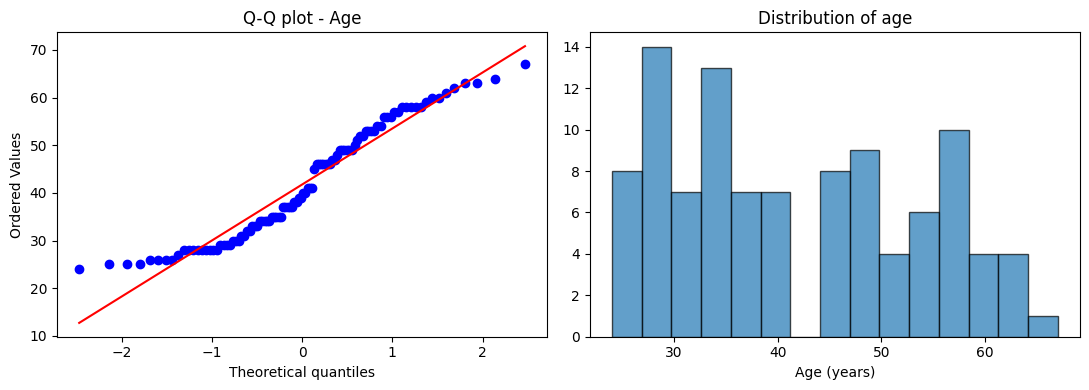


Categorical variables - n (%)

--- Age group ---
  ≤35 years: 42 (41.2%)
  36–50 years: 32 (31.4%)
  >50 years: 28 (27.5%)

--- Sex ---
  Muller: 84 (82.4%)
  Home: 18 (17.6%)

--- Experience ---
  >10 anos: 64 (62.7%)
  6-10 anos: 20 (19.6%)
  1-5 anos: 18 (17.6%)

--- Education ---
  Grado: 68 (66.7%)
  Máster: 32 (31.4%)
  Doutorado: 2 (2.0%)

--- Health area ---
  Santiago-Barbanza: 81 (79.4%)
  Ourense-Verín-O Barco: 6 (5.9%)
  Vigo: 5 (4.9%)
  A Coruña-Cee: 3 (2.9%)
  Pontevedra-Salnés: 3 (2.9%)
  Lugo-A Mariña-Monforte: 2 (2.0%)
  Ferrol: 2 (2.0%)

--- Setting ---
  Urbano: 51 (50.0%)
  Rural: 51 (50.0%)

--- Tech frequency ---
  Frecuentemente: 32 (31.4%)
  Sempre: 27 (26.5%)
  Ás veces: 26 (25.5%)
  Raramente: 11 (10.8%)
  Nunca: 6 (5.9%)

--- AI understanding ---
  Bastante: 41 (40.2%)
  Algo: 41 (40.2%)
  Pouco: 15 (14.7%)
  Totalmente: 4 (3.9%)
  Nada: 1 (1.0%)

--- AI clinical use ---
  Non: 60 (58.8%)
  Non sei: 22 (21.6%)
  Sí: 20 (19.6%)

--- Prior training ---
  Ningu

In [19]:
print('=' * 70)
print('TABLE 1 - Descriptive analysis with assumption checks')
print('=' * 70)

# Normality of age
age = df['age'].dropna()
W, pW = stats.shapiro(age)
D, pD = stats.kstest(age, 'norm', args=(age.mean(), age.std()))
print('\nAssumption check - Normality of age')
print(f'  Shapiro-Wilk:       W = {W:.4f}, p = {pW:.4f}')
print(f'  Kolmogorov-Smirnov: D = {D:.4f}, p = {pD:.4f}')
print('  Non-normal (Shapiro p < 0.05): reporting mean +/- SD and median [IQR].')

ci = stats.t.interval(0.95, len(age) - 1, age.mean(), stats.sem(age))
print(f'\n  Age - mean {age.mean():.2f} +/- {age.std():.2f} '
      f'(95% CI {ci[0]:.2f}-{ci[1]:.2f})')
print(f'        median {age.median():.1f} [IQR {age.quantile(.25):.1f}-{age.quantile(.75):.1f}] '
      f'range {age.min():.0f}-{age.max():.0f}')

# Q-Q plot and histogram
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(age, dist='norm', plot=ax[0])
ax[0].set_title('Q-Q plot - Age')
ax[1].hist(age, bins=15, edgecolor='black', alpha=.7)
ax[1].set_title('Distribution of age')
ax[1].set_xlabel('Age (years)')
plt.tight_layout()
plt.savefig('age_normality.png', dpi=300, bbox_inches='tight')
plt.show()

# Categorical descriptives (Table 1)
print('\nCategorical variables - n (%)')
categorical = {
    'Age group': 'age_group', 'Sex': 'sex', 'Experience': 'experience',
    'Education': 'education', 'Health area': 'health_area', 'Setting': 'setting',
    'Tech frequency': 'tech_freq', 'AI understanding': 'ai_understanding',
    'AI clinical use': 'ai_clinical_use', 'Prior training': 'ai_training_received',
    'Wants training': 'wants_training', 'Training importance': 'training_importance',
}
for label, c in categorical.items():
    print(f'\n--- {label} ---')
    counts = df[c].value_counts(dropna=False)
    pcts   = df[c].value_counts(normalize=True, dropna=False) * 100
    for cat in counts.index:
        print(f'  {cat}: {counts[cat]} ({pcts[cat]:.1f}%)')

## 5. SHAIP item- and construct-level scores (Table 2)

Mean, standard deviation and 95% confidence interval for each SHAIP item and for
the two a priori constructs (Professional Impact = items 1–6; Preparedness =
items 7–10). Confidence intervals are based on Student's t distribution, which is
appropriate for the per-item means at n = 102.

These are descriptive summaries of the scale as originally specified. The
internal consistency of these constructs, and the behaviour of individual items
within them, are examined in Section 6.

In [20]:
print('=' * 70)
print('TABLE 2 - SHAIP item-level and construct-level descriptives')
print('=' * 70)

def describe_item(series, label):
    s = series.dropna()
    n = len(s); mean, sd = s.mean(), s.std()
    ci = stats.t.interval(0.95, n - 1, mean, stats.sem(s))
    return {'Item': label, 'n': n, 'Mean': round(mean, 2),
            'SD': round(sd, 2), '95% CI': f'[{ci[0]:.2f}, {ci[1]:.2f}]'}

rows = [describe_item(df['impact_score'], 'Professional Impact (construct)')]
rows += [describe_item(df[f'item{i}'], f'Item {i}') for i in range(1, 7)]
rows += [describe_item(df['readiness_score'], 'Preparedness (construct)')]
rows += [describe_item(df[f'item{i}'], f'Item {i}') for i in range(7, 11)]

table2_df = pd.DataFrame(rows)
print(table2_df.to_string(index=False))

TABLE 2 - SHAIP item-level and construct-level descriptives
                           Item   n  Mean   SD       95% CI
Professional Impact (construct) 102  3.98 0.60 [3.87, 4.10]
                         Item 1 102  4.07 0.72 [3.93, 4.21]
                         Item 2 102  4.07 0.69 [3.93, 4.20]
                         Item 3 102  4.03 0.76 [3.88, 4.18]
                         Item 4 102  3.91 0.90 [3.73, 4.09]
                         Item 5 102  3.58 0.97 [3.39, 3.77]
                         Item 6 102  4.25 0.65 [4.12, 4.37]
       Preparedness (construct) 102  2.60 0.66 [2.47, 2.73]
                         Item 7 102  2.48 1.01 [2.28, 2.68]
                         Item 8 102  1.75 1.01 [1.55, 1.94]
                         Item 9 102  2.76 1.20 [2.53, 3.00]
                        Item 10 102  3.41 1.16 [3.18, 3.64]


## 6. Psychometric analysis: factor structure and reliability (S1 Table)

This section evaluates the measurement properties of the SHAIP instrument in the
present sample. Sampling adequacy and factorability are checked before the
exploratory factor analysis (EFA), and reliability is assessed with both
Cronbach's alpha and McDonald's omega. Alpha assumes tau-equivalence (equal
loadings), which is not guaranteed here; omega is the more robust coefficient
when that assumption is relaxed.

**Factorability checks:** Kaiser–Meyer–Olkin (KMO) overall and per item;
Bartlett's test of sphericity; the determinant of the correlation matrix; and
the subject-to-variable ratio.

**EFA:** two factors (theory-driven), principal axis factoring extraction with
varimax rotation, reporting loadings, explained variance and communalities.

**Item 10 (legal responsibility).** The a priori four-item Preparedness subscale
shows poor internal consistency. Several convergent diagnostics indicate that
item 10 does not behave as part of the Preparedness construct: a negative rotated
loading on the Preparedness factor, the lowest communality of the scale, a
per-item KMO well below the rest, a negative corrected item-total correlation,
and the largest increase in alpha when the item is removed. Item 10 is therefore
reported separately as an indicator of perceived legal accountability, and a
refined three-item Preparedness subscale (items 7–9) is used in the subsequent
analyses.

In [21]:
print('=' * 70)
print('S1 TABLE - Psychometric analysis')
print('=' * 70)

from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from factor_analyzer import FactorAnalyzer

all_items    = [f'item{i}' for i in range(1, 11)]
impact_items = [f'item{i}' for i in range(1, 7)]
readiness4   = [f'item{i}' for i in range(7, 11)]   # a priori
readiness3   = ['item7', 'item8', 'item9']          # refined
items_df = df[all_items]

# Factorability
kmo_item, kmo = calculate_kmo(items_df)
chi, bart_p   = calculate_bartlett_sphericity(items_df)
det           = np.linalg.det(items_df.corr().values)
print(f'\nKMO overall = {kmo:.3f}   Bartlett chi2 = {chi:.2f}, p = {bart_p:.2e}')
print(f'Determinant = {det:.6f} (>1e-5 acceptable)   '
      f'Subject:variable ratio = {len(items_df)/10:.1f}:1')
print('KMO per item:', '  '.join(f'i{i+1}={k:.2f}' for i, k in enumerate(kmo_item)))

# Exploratory factor analysis
fa = FactorAnalyzer(n_factors=2, rotation='varimax', method='principal')
fa.fit(items_df)
loadings = pd.DataFrame(fa.loadings_, index=all_items,
                        columns=['F1 (Impact)', 'F2 (Preparedness)']).round(3)
ev, v, cumv = fa.get_factor_variance()
com = pd.Series(fa.get_communalities(), index=all_items)
print('\nEFA - varimax loadings:')
print(loadings.to_string())
print(f'\nVariance: F1 = {v[0]*100:.2f}%  F2 = {v[1]*100:.2f}%  '
      f'cumulative = {cumv[1]*100:.2f}%')
print('Communalities:', '  '.join(f'i{i+1}={c:.2f}' for i, c in enumerate(com)))

# Reliability: alpha and omega
def mcdonald_omega(data):
    fa1 = FactorAnalyzer(n_factors=1, rotation=None, method='minres')
    fa1.fit(data)
    l = fa1.loadings_[:, 0]
    return (l.sum()**2) / (l.sum()**2 + (1 - l**2).sum())

print('\nReliability (Cronbach alpha with 95% CI, and McDonald omega):')
for items, lab in [(impact_items, 'Impact (6 items)'),
                   (readiness4, 'Preparedness (4 items, a priori)'),
                   (readiness3, 'Preparedness (3 items, refined)')]:
    a, ci = pg.cronbach_alpha(data=df[items], ci=.95)
    print(f'  {lab:34s} alpha = {a:.3f} [{ci[0]:.3f}, {ci[1]:.3f}]   '
          f'omega = {mcdonald_omega(df[items]):.3f}')

# Item-level diagnostics within the a priori subscale
print('\nItem-level diagnostics (Preparedness 4-item subscale):')
d = df[readiness4]
a4, _ = pg.cronbach_alpha(data=d)
for it in readiness4:
    rest = d.drop(columns=[it]).sum(axis=1)
    r = d[it].corr(rest)
    a_del, _ = pg.cronbach_alpha(data=d.drop(columns=[it]))
    flag = '  (removal increases alpha)' if a_del > a4 else ''
    print(f'  {it}: corrected item-total r = {r:+.3f}   '
          f'alpha-if-deleted = {a_del:.3f}{flag}')

# Refined subscale score
df['readiness3_score'] = df[readiness3].mean(axis=1)
s = df['readiness3_score']
ci = stats.t.interval(.95, len(s) - 1, s.mean(), stats.sem(s))
print(f'\nRefined Preparedness (3 items): mean = {s.mean():.2f} '
      f'(SD {s.std():.2f}, 95% CI [{ci[0]:.2f}, {ci[1]:.2f}]); '
      f'4-item a priori mean = 2.60')
print(f'Item 10 retained separately as a legal-accountability indicator '
      f'(mean {df["item10"].mean():.2f}).')

S1 TABLE - Psychometric analysis

KMO overall = 0.813   Bartlett chi2 = 347.88, p = 2.03e-48
Determinant = 0.027529 (>1e-5 acceptable)   Subject:variable ratio = 10.2:1
KMO per item: i1=0.83  i2=0.84  i3=0.81  i4=0.81  i5=0.91  i6=0.90  i7=0.70  i8=0.71  i9=0.69  i10=0.41

EFA - varimax loadings:
        F1 (Impact)  F2 (Preparedness)
item1         0.760              0.164
item2         0.840             -0.036
item3         0.870              0.088
item4         0.713             -0.072
item5         0.633              0.130
item6         0.786              0.095
item7         0.195              0.755
item8         0.123              0.731
item9         0.141              0.764
item10        0.118             -0.331

Variance: F1 = 36.54%  F2 = 18.63%  cumulative = 55.17%
Communalities: i1=0.60  i2=0.71  i3=0.77  i4=0.51  i5=0.42  i6=0.63  i7=0.61  i8=0.55  i9=0.60  i10=0.12

Reliability (Cronbach alpha with 95% CI, and McDonald omega):
  Impact (6 items)                   alpha = 0.8

In [40]:
fa_obl = FactorAnalyzer(n_factors=2, rotation='promax', method='principal')
fa_obl.fit(items_df)

loadings_obl = pd.DataFrame(fa_obl.loadings_, index=all_items,
                            columns=['F1 (Impact)', 'F2 (Preparedness)']).round(3)
phi = fa_obl.phi_

print('EFA - cargas con rotación oblicua (promax):')
print(loadings_obl.to_string())
print(f'\nCorrelación entre factores (phi) = {phi[0, 1]:+.3f}')
if abs(phi[0, 1]) < 0.32:
    print('Interpretación: |phi| < 0.32 (≈10% varianza compartida): los factores son')
    print('prácticamente ortogonales; la solución varimax queda respaldada.')
else:
    print('Interpretación: |phi| >= 0.32: los factores correlacionan de forma apreciable;')
    print('la solución oblicua es la más defendible y debe ser la reportada.')

EFA - cargas con rotación oblicua (promax):
        F1 (Impact)  F2 (Preparedness)
item1         0.754              0.111
item2         0.849             -0.096
item3         0.871              0.028
item4         0.724             -0.122
item5         0.629              0.086
item6         0.785              0.040
item7         0.143              0.747
item8         0.072              0.727
item9         0.087              0.759
item10        0.142             -0.342

Correlación entre factores (phi) = +0.140
Interpretación: |phi| < 0.32 (≈10% varianza compartida): los factores son
prácticamente ortogonales; la solución varimax queda respaldada.


## 7. Bivariate analysis: AI users vs non-users (S2 Table)

Sociodemographic, professional and training characteristics are compared between
AI users (n = 20) and non-users (n = 82), using the full sample with "Non sei"
responses treated as non-users (Section 3).

**Test selection.** For each categorical predictor, expected cell frequencies
are inspected. When any expected frequency is below 5, Fisher's exact test is
used; otherwise Pearson's chi-square with Yates' continuity correction is
applied, the conventional standard for 2×2 tables. Odds ratios with 95% CI are
reported; a Haldane–Anscombe (+0.5) correction is applied only when a zero cell
is present.

**Age.** Because age departs from normality and the user group is small
(n = 20), the between-group comparison uses the Mann–Whitney U test, with medians
[IQR] reported.

In [22]:
print('=' * 70)
print('S2 TABLE - AI users vs non-users')
print('=' * 70)
print(f'Users: {(df.ai_user==1).sum()}   Non-users: {(df.ai_user==0).sum()}\n')

def or_2x2(t):
    a, b = t[0]; c, d = t[1]
    if 0 in [a, b, c, d]:           # Haldane-Anscombe only if a zero cell is present
        a, b, c, d = a + .5, b + .5, c + .5, d + .5
    orr = (a * d) / (b * c)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    lo = np.log(orr)
    return orr, np.exp(lo - 1.96 * se), np.exp(lo + 1.96 * se)

def bivariate(var, label):
    ct = pd.crosstab(df[var], df['ai_user'])
    chi2, p, dof, exp = stats.chi2_contingency(ct.values)   # Yates correction (default)
    o, l, h = or_2x2(ct.values)
    print(f'--- {label} ---')
    if exp.min() < 5:
        _, p = stats.fisher_exact(ct.values)
        print(f'  min expected = {exp.min():.2f} (<5): Fisher exact test')
        print(f'  OR = {o:.2f} (95% CI {l:.2f}-{h:.2f}), p = {p:.3f}\n')
    else:
        print(f'  min expected = {exp.min():.2f}: chi-square with Yates correction')
        print(f'  chi2 = {chi2:.2f}, df = {dof}, p = {p:.3f}; '
              f'OR = {o:.2f} (95% CI {l:.2f}-{h:.2f})\n')

bivariate('sex',          'Sex (female vs male)')
bivariate('postgraduate', 'Education (postgraduate vs bachelor)')
bivariate('urban',        'Setting (urban vs rural)')
bivariate('has_training', 'Prior AI training (any vs none)')

# Age: non-parametric comparison
u  = df.loc[df.ai_user == 1, 'age']
nu = df.loc[df.ai_user == 0, 'age']
U, pU = stats.mannwhitneyu(u, nu)
print('--- Age (continuous, non-normal) ---')
print(f'  Users:     median {u.median():.1f} [IQR {u.quantile(.25):.0f}-{u.quantile(.75):.0f}]')
print(f'  Non-users: median {nu.median():.1f} [IQR {nu.quantile(.25):.0f}-{nu.quantile(.75):.0f}]')
print(f'  Mann-Whitney U p = {pU:.3f}')

S2 TABLE - AI users vs non-users
Users: 20   Non-users: 82

--- Sex (female vs male) ---
  min expected = 3.53 (<5): Fisher exact test
  OR = 0.82 (95% CI 0.24-2.84), p = 0.749

--- Education (postgraduate vs bachelor) ---
  min expected = 6.67: chi-square with Yates correction
  chi2 = 0.19, df = 1, p = 0.659; OR = 1.44 (95% CI 0.52-3.94)

--- Setting (urban vs rural) ---
  min expected = 10.00: chi-square with Yates correction
  chi2 = 1.55, df = 1, p = 0.212; OR = 0.47 (95% CI 0.17-1.28)

--- Prior AI training (any vs none) ---
  min expected = 6.08: chi-square with Yates correction
  chi2 = 5.75, df = 1, p = 0.017; OR = 3.79 (95% CI 1.37-10.45)

--- Age (continuous, non-normal) ---
  Users:     median 36.5 [IQR 31-53]
  Non-users: median 40.0 [IQR 31-52]
  Mann-Whitney U p = 0.866


In [43]:
from statsmodels.stats.multitest import multipletests

def _p_cat(var):
    ct = pd.crosstab(df[var], df['ai_user']).values
    _, p, _, exp = stats.chi2_contingency(ct)
    if exp.min() < 5:
        _, p = stats.fisher_exact(ct)
    return p

tests = {'Sex': 'sex', 'Education': 'postgraduate',
         'Setting': 'urban', 'Prior training': 'has_training'}
labels = list(tests.keys())
praw = [_p_cat(v) for v in tests.values()]

p_holm = multipletests(praw, method='holm')[1]
p_bh   = multipletests(praw, method='fdr_bh')[1]

print('Corrección por multiplicidad (4 contrastes bivariados):')
print(f'{"Variable":16s}{"p crudo":>9s}{"p Holm":>9s}{"p BH":>9s}')
for lab, pr, ph, pb in zip(labels, praw, p_holm, p_bh):
    print(f'{lab:16s}{pr:9.3f}{ph:9.3f}{pb:9.3f}')
print('\nNota: "formación previa" debe enmarcarse como hallazgo exploratorio.')

Corrección por multiplicidad (4 contrastes bivariados):
Variable          p crudo   p Holm     p BH
Sex                 0.749    1.000    0.749
Education           0.659    1.000    0.749
Setting             0.212    0.637    0.425
Prior training      0.017    0.066    0.066

Nota: "formación previa" debe enmarcarse como hallazgo exploratorio.


## 8. Multivariable analysis: Firth-penalized logistic regression (Table 3)

Independent predictors of self-reported clinical AI use are modelled with prior
training, setting, education and age as covariates.

**Rationale for Firth's method.** With 20 events and 4 covariates the
events-per-variable ratio is 5:1, below the conventional 10:1. Firth's penalized
maximum likelihood (Jeffreys prior) reduces small-sample bias and yields finite
estimates under near-separation.

**Inference.** Confidence intervals are obtained by profile penalized likelihood
and p-values by the penalized likelihood-ratio test rather than Wald
approximations. In small samples these are more reliable and need not be
symmetric (Heinze & Schemper, 2002). Point estimates are cross-checked against
standard maximum likelihood.

**Assumptions checked:** events-per-variable ratio; multicollinearity (VIF);
linearity of the logit for age (Box–Tidwell); influential observations (Cook's
distance); goodness of fit (Hosmer–Lemeshow); discrimination (AUC).

**Robustness.** Because 22 respondents answered "Non sei" and were treated as
non-users, the model is refitted excluding them (sensitivity analysis).

In [23]:
print('=' * 70)
print('TABLE 3 - Firth-penalized logistic regression')
print('=' * 70)

# Firth helpers
def firth_loglik(beta, X, y):
    eta = np.clip(X @ beta, -30, 30); mu = 1 / (1 + np.exp(-eta)); W = mu * (1 - mu)
    _, logdet = np.linalg.slogdet(X.T @ (X * W[:, None]))
    return np.sum(y * eta - np.log1p(np.exp(eta))) + 0.5 * logdet

def firth_fit(X, y, max_iter=1000, tol=1e-8):
    beta = np.zeros(X.shape[1])
    for _ in range(max_iter):
        eta = np.clip(X @ beta, -30, 30); mu = 1 / (1 + np.exp(-eta)); W = mu * (1 - mu)
        inv = np.linalg.pinv(X.T @ (X * W[:, None])); sqW = np.sqrt(W)
        H = np.diagonal((sqW[:, None] * X) @ inv @ (X.T * sqW))
        delta = inv @ (X.T @ (y - mu + H * (0.5 - mu))); beta = beta + delta
        if np.max(np.abs(delta)) < tol: break
    return beta

def _profile_ll(X, y, j, vj):
    from scipy.optimize import minimize
    idx = [k for k in range(X.shape[1]) if k != j]; b0 = firth_fit(X, y)[idx]
    def negll(bf):
        b = np.empty(X.shape[1]); b[j] = vj; b[idx] = bf
        return -firth_loglik(b, X, y)
    return -minimize(negll, b0, method='Nelder-Mead',
                     options={'xatol': 1e-6, 'fatol': 1e-8, 'maxiter': 5000}).fun

def profile_ci(X, y, j, ll_hat, bj, crit=3.841459):
    from scipy.optimize import brentq
    f = lambda v: 2 * (ll_hat - _profile_ll(X, y, j, v)) - crit
    lo = brentq(f, bj - 10, bj - 1e-4, xtol=1e-5)
    hi = brentq(f, bj + 1e-4, bj + 10, xtol=1e-5)
    return lo, hi

def plr_p(X, y, j, ll_hat):
    lr = 2 * (ll_hat - _profile_ll(X, y, j, 0.0))
    return lr, 1 - stats.chi2.cdf(lr, 1)

# Data matrix
preds = ['has_training', 'urban', 'postgraduate', 'age']
Xdf = sm.add_constant(df[preds])
X = Xdf.values.astype(float); y = df['ai_user'].values.astype(float)
names = ['const'] + preds

# Assumptions
print(f'\nEPV = {int(y.sum())}/4 = {int(y.sum())/4:.1f}  (Firth applied)')
print('VIF:', '  '.join(f'{c}={variance_inflation_factor(X, i):.2f}'
                        for i, c in enumerate(Xdf.columns)))
age_s = df['age'].clip(lower=.1)
Xbt = sm.add_constant(pd.DataFrame({'has_training': df.has_training, 'urban': df.urban,
      'postgraduate': df.postgraduate, 'age': df.age, 'age_ln': age_s * np.log(age_s)}))
p_bt = sm.Logit(df.ai_user, Xbt).fit(disp=False).pvalues['age_ln']
print(f'Box-Tidwell (age): p = {p_bt:.4f}  '
      f'(logit linearity {"met" if p_bt > .05 else "violated"})')
ml = sm.Logit(df.ai_user, Xdf).fit(disp=False)
cook = ml.get_influence().cooks_distance[0]
print(f"Influential observations (Cook's D > 1): {(cook > 1).sum()}  "
      f"(max Cook's D = {cook.max():.3f})")

# Fit and profile-likelihood inference (Table 3)
bhat = firth_fit(X, y); ll_hat = firth_loglik(bhat, X, y)
print('\nVariable        beta      OR     95% CI (profile)     p (PLR)')
for j, v in enumerate(names):
    if v == 'const': continue
    lo, hi = profile_ci(X, y, j, ll_hat, bhat[j]); _, p = plr_p(X, y, j, ll_hat)
    print(f'{v:14s}{bhat[j]:7.3f}{np.exp(bhat[j]):8.3f}   '
          f'({np.exp(lo):.2f}-{np.exp(hi):.2f}){"":6}{p:.3f}')

# Cross-check against standard maximum likelihood
print('\nCross-check (point OR): Firth vs standard ML')
for v in preds:
    print(f'  {v:13s} Firth OR = {np.exp(bhat[names.index(v)]):.3f} | '
          f'ML OR = {np.exp(ml.params[v]):.3f}')

TABLE 3 - Firth-penalized logistic regression

EPV = 20/4 = 5.0  (Firth applied)
VIF: const=19.49  has_training=1.02  urban=1.03  postgraduate=1.11  age=1.12
Box-Tidwell (age): p = 0.3623  (logit linearity met)
Influential observations (Cook's D > 1): 0  (max Cook's D = 0.103)

Variable        beta      OR     95% CI (profile)     p (PLR)
has_training    1.317   3.732   (1.37-10.54)      0.010
urban          -0.845   0.430   (0.14-1.20)      0.107
postgraduate    0.170   1.186   (0.40-3.40)      0.753
age            -0.008   0.992   (0.95-1.04)      0.714

Cross-check (point OR): Firth vs standard ML
  has_training  Firth OR = 3.732 | ML OR = 4.036
  urban         Firth OR = 0.430 | ML OR = 0.401
  postgraduate  Firth OR = 1.186 | ML OR = 1.183
  age           Firth OR = 0.992 | ML OR = 0.991


Goodness of fit and discrimination

  Hosmer-Lemeshow: chi2 = 10.04, df = 8, p = 0.262
  AUC (apparent) = 0.705


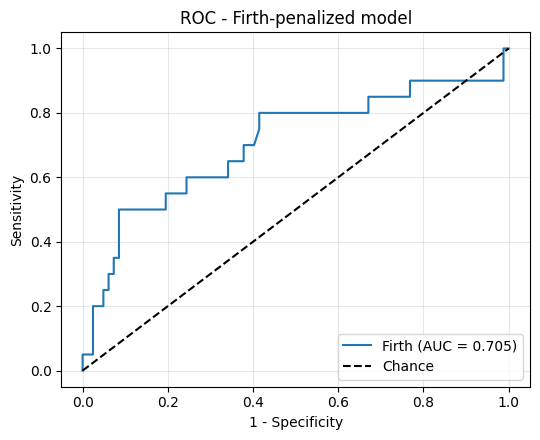

In [24]:
print('Goodness of fit and discrimination\n')
eta = np.clip(X @ bhat, -30, 30); prob = 1 / (1 + np.exp(-eta))

# Hosmer-Lemeshow
dfh = pd.DataFrame({'y': y, 'p': prob})
dfh['g'] = pd.qcut(dfh.p, 10, duplicates='drop')
o = dfh.groupby('g', observed=True)['y'].agg(['sum', 'count'])
e = dfh.groupby('g', observed=True)['p'].sum()
o['e'] = e; o['eno'] = o['count'] - o['e']; o['ono'] = o['count'] - o['sum']
hl = (((o['sum'] - o['e'])**2 / o['e']) +
      ((o['ono'] - o['eno'])**2 / o['eno'])).sum()
hldf = len(o) - 2
print(f'  Hosmer-Lemeshow: chi2 = {hl:.2f}, df = {hldf}, '
      f'p = {1 - stats.chi2.cdf(hl, hldf):.3f}')

# Apparent discrimination (AUC) and ROC
auc = roc_auc_score(y, prob)
print(f'  AUC (apparent) = {auc:.3f}')
fpr, tpr, _ = roc_curve(y, prob)
plt.figure(figsize=(5.5, 4.5))
plt.plot(fpr, tpr, label=f'Firth (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('1 - Specificity'); plt.ylabel('Sensitivity')
plt.legend(loc='lower right')
plt.title('ROC - Firth-penalized model'); plt.grid(alpha=.3)
plt.tight_layout()
plt.savefig('roc_firth.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
print('Sensitivity analysis - excluding "Non sei" responses\n')
dfs = df[df.ai_clinical_use.isin(['Sí', 'Non'])]
Xs = sm.add_constant(dfs[preds]).values.astype(float)
ys = dfs['ai_user'].values.astype(float)
bs = firth_fit(Xs, ys); lls = firth_loglik(bs, Xs, ys)
print(f'  n = {len(dfs)} (vs 102), events = {int(ys.sum())}, EPV = {int(ys.sum())/4:.1f}')
print('\n  Variable        OR      95% CI (profile)     p')
for j, v in enumerate(names):
    if v == 'const': continue
    lo, hi = profile_ci(Xs, ys, j, lls, bs[j]); _, p = plr_p(Xs, ys, j, lls)
    print(f'  {v:13s}{np.exp(bs[j]):7.3f}   ({np.exp(lo):.2f}-{np.exp(hi):.2f}){"":6}{p:.3f}')
print('\n  Prior training remains the only significant predictor '
      '(direction unchanged).')

Sensitivity analysis - excluding "Non sei" responses

  n = 80 (vs 102), events = 20, EPV = 5.0

  Variable        OR      95% CI (profile)     p
  has_training   2.996   (1.07-8.72)      0.037
  urban          0.375   (0.12-1.05)      0.063
  postgraduate   1.035   (0.34-3.05)      0.950
  age            1.007   (0.96-1.06)      0.751

  Prior training remains the only significant predictor (direction unchanged).


In [42]:
rng = np.random.default_rng(42)
B = 500
optimism = []
for _ in range(B):
    idx = rng.choice(len(y), len(y), replace=True)
    Xb, yb = X[idx], y[idx]
    if len(np.unique(yb)) < 2 or yb.sum() < 3 or (len(yb) - yb.sum()) < 3:
        continue  # remuestreo degenerado: se descarta
    try:
        bb = firth_fit(Xb, yb)
    except Exception:
        continue
    pb = 1 / (1 + np.exp(-np.clip(Xb @ bb, -30, 30)))
    po = 1 / (1 + np.exp(-np.clip(X  @ bb, -30, 30)))
    optimism.append(roc_auc_score(yb, pb) - roc_auc_score(y, po))

opt = np.mean(optimism)
print(f'AUC aparente            = {auc:.3f}')
print(f'Optimismo (bootstrap)   = {opt:.3f}   (sobre {len(optimism)} remuestreos válidos de {B})')
print(f'AUC corregido           = {auc - opt:.3f}')

AUC aparente            = 0.705
Optimismo (bootstrap)   = 0.065   (sobre 500 remuestreos válidos de 500)
AUC corregido           = 0.639


## 9. Qualitative component: directed content analysis of open-ended responses (Table 4)

The two open-ended questions (perceived barriers; training interests) are
analysed with a directed (deductive) content-analysis approach. A predefined
dictionary of terms (codebook) operationalises each category, and each response
is coded by matching its text against the category terms. Coding is lexical and
rule-based (case-insensitive term matching), not interpretive thematic analysis,
and does not involve natural-language-processing models. Categories are not
mutually exclusive (a response may map to several), so prevalence is reported as
the percentage of respondents mentioning each category; percentages therefore
sum to more than 100%.

The dictionary-based coding provides the initial automated pass. Its reliability
against independent human coding is reported in Section 9.1, where disagreements
are resolved by consensus. The full codebook is printed below for reproducibility.

In [38]:
print('=' * 70)
print('TABLE 4 - Directed content analysis (dictionary-based)')
print('=' * 70)

# Codebook (predefined dictionaries)
barrier_codebook = {
    'Lack of Training / Knowledge': ['formación', 'formacion', 'training', 'knowledge',
        'coñecemento', 'conocimiento', 'desconocimiento', 'descoñecemento',
        'información', 'informacion', 'preparación', 'preparacion'],
    'Ethics and Privacy': ['ética', 'etico', 'ethics', 'privacy', 'privacidade',
        'confidencialidad', 'confidencialidade', 'datos', 'data', 'security',
        'seguridad', 'seguridade'],
    'Implementation / Technology': ['implementación', 'implementacion', 'integración',
        'integracion', 'tecnoloxía', 'tecnologia', 'software', 'desarrollo', 'desenvolvemento'],
    'Resources (Time / Infrastructure)': ['tempo', 'tiempo', 'recursos',
        'infraestructura', 'infrastructure'],
    'Economic Cost': ['económico', 'economico', 'económica', 'economica',
        'coste', 'custo', 'desembolso', 'presupuesto'],
    'Resistance to Change / Fear': ['medo', 'miedo', 'fear', 'reticencia',
        'reluctancia', 'humanización'],
}

def code_response(text, codebook):
    if pd.isna(text): return []
    t = str(text).lower().strip()
    if not t or t in ['.', ',', '-']: return []
    matched = [cat for cat, terms in codebook.items() if any(term in t for term in terms)]
    return matched if matched else ['Others / Non-specific']

df['barriers_codes'] = df['barriers_open'].apply(lambda x: code_response(x, barrier_codebook))

def prevalence(col, label):
    print(f'\n--- {label} (n responses = '
          f'{df[col].apply(lambda c: len(c) > 0).sum()}) ---')
    flat = [c for sub in df[col] for c in sub]
    for cat, n in pd.Series(flat).value_counts().items():
        print(f'  {cat}: {n} ({n/len(df)*100:.1f}%)')

prevalence('barriers_codes', 'Barriers to AI integration')

# Codebook printout for the supplementary material
print('\nCodebook (barriers):')
for cat, terms in barrier_codebook.items():
    print(f'  {cat}: {", ".join(terms)}')

TABLE 4 - Directed content analysis (dictionary-based)

--- Barriers to AI integration (n responses = 101) ---
  Lack of Training / Knowledge: 80 (78.4%)
  Ethics and Privacy: 18 (17.6%)
  Implementation / Technology: 17 (16.7%)
  Economic Cost: 12 (11.8%)
  Resources (Time / Infrastructure): 12 (11.8%)
  Others / Non-specific: 11 (10.8%)
  Resistance to Change / Fear: 2 (2.0%)

Codebook (barriers):
  Lack of Training / Knowledge: formación, formacion, training, knowledge, coñecemento, conocimiento, desconocimiento, descoñecemento, información, informacion, preparación, preparacion
  Ethics and Privacy: ética, etico, ethics, privacy, privacidade, confidencialidad, confidencialidade, datos, data, security, seguridad, seguridade
  Implementation / Technology: implementación, implementacion, integración, integracion, tecnoloxía, tecnologia, software, desarrollo, desenvolvemento
  Resources (Time / Infrastructure): tempo, tiempo, recursos, infraestructura, infrastructure
  Economic Cost: e

In [31]:
from google.colab import files

training_codebook = {
    "Don't know / No specific area": ['non sei','no sei','non o sei','no sé','no se','nin idea',
        'no lo sé','no lo se','desconoz','non pode opinar','non teño','no está de más',
        'ningunha','ninguna','non nacin','costame'],
    'General / Any area': ['en general','en xeral','en todas','en moitas','calquera','cualquier',
        'todas as posibles','todas las','toda las','amplio abanico','todo lo relacionado',
        'todo e receptivo','integral','maximas posibles','las relacionadas','abierta a toda',
        'posibilidades','todas aquelas','todas aquellas'],
    'Clinical Application and Care': ['clínica','clinica','coidado','cuidado','feridas','heridas',
        'tratamiento','tratamento','decision','decisión','ecg','diagn','crónico','cronico',
        'consulta','urx','urgencias','curas','protocolo','dosificación','medicación','paciente',
        'recomendaci','síntomas','sintomas','práctica','practica','epidemio','xestión','gestión',
        'saúde','sanitari','enfermeria','enfermaría','especialidade'],
    'Tool Use / AI Fundamentals': ['ferramenta','herramienta','uso da','uso de prompts',
        'informátic','informatic','funcionamiento','modelos de la ia','como usarla',
        'usos e aplicaci','aplicación da ia','aplicación de la ia','aplicación na','manexa',
        'manejar','optimización','personalizacion'],
    'Research': ['investigaci','bibliograf','análise','analise de inform'],
    'Ethics and Legality': ['ética','etica','legal'],
}
t_categories = list(training_codebook.keys()) + ['Others / Non-specific']

def code_response_t(text, codebook):
    if pd.isna(text): return []
    t = str(text).lower().strip()
    if not t or t in ['.', ',', '-']: return []
    matched = [cat for cat, terms in codebook.items() if any(term in t for term in terms)]
    return matched if matched else ['Others / Non-specific']

df['training_codes'] = df['training_areas_open'].apply(lambda x: code_response_t(x, training_codebook))

print('Training-area interests - initial dictionary pass (% of 102):')
flat = [c for sub in df['training_codes'] for c in sub]
for cat, n in pd.Series(flat).value_counts().items():
    print(f'  {cat}: {n} ({n/len(df)*100:.1f}%)')

mask = df['training_areas_open'].apply(
    lambda x: not (pd.isna(x) or str(x).strip() in ['', '.', ',', '-']))
template_t = pd.DataFrame({'id': df.index[mask],
                           'response_text': df.loc[mask, 'training_areas_open'].values})
for c in t_categories:
    template_t[c] = ''
template_t.to_excel('coding_template_training.xlsx', index=False)
print(f'\nTemplate: {template_t.shape[0]} responses x {len(t_categories)} categories')
print('Duplicate as Revisor_1_formacion / Revisor_2_formacion and code each (1=present, 0=absent).')
files.download('coding_template_training.xlsx')

Training-area interests - initial dictionary pass (% of 102):
  Don't know / No specific area: 48 (47.1%)
  Clinical Application and Care: 31 (30.4%)
  General / Any area: 20 (19.6%)
  Tool Use / AI Fundamentals: 13 (12.7%)
  Research: 4 (3.9%)
  Ethics and Legality: 2 (2.0%)

Template: 99 responses x 7 categories
Duplicate as Revisor_1_formacion / Revisor_2_formacion and code each (1=present, 0=absent).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 9.1 Inter-coder reliability

To assess the reliability of the directed content-analysis coding scheme, all
101 open-ended barrier responses were independently coded by two qualified coders
using the predefined codebook, working blind to each other. Agreement was
quantified with Cohen's kappa per category and as the mean across categories.

Because the categories are not mutually exclusive, kappa is computed per category
(presence/absence) and then averaged. Disagreements were subsequently resolved by
consensus, and the consensus coding is the one reported in Table 4.

In [ ]:
from google.colab import files

categories = ['Lack of Training / Knowledge', 'Ethics and Privacy',
              'Implementation / Technology', 'Resources (Time / Infrastructure)',
              'Economic Cost', 'Resistance to Change / Fear', 'Others / Non-specific']

mask = df['barriers_open'].apply(
    lambda x: not (pd.isna(x) or str(x).strip() in ['', '.', ',', '-']))
template = pd.DataFrame({'id': df.index[mask],
                         'response_text': df.loc[mask, 'barriers_open'].values})
for c in categories:
    template[c] = ''   # each coder fills 1 (present) / 0 (absent)

template.to_excel('coding_template.xlsx', index=False)
print(f'Template: {template.shape[0]} responses x {len(categories)} categories')
print('Rule: mark "Others / Non-specific" = 1 only if no substantive category applies.')
print('Duplicate for each coder (Revisor_1, Revisor_2).')
files.download('coding_template.xlsx')

Template: 101 responses x 7 categories
Rule: mark "Others / Non-specific" = 1 only if no substantive category applies.
Duplicate for each coder (Revisor_1, Revisor_2).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
from sklearn.metrics import cohen_kappa_score

categories = ['Lack of Training / Knowledge', 'Ethics and Privacy', 'Implementation / Technology',
              'Resources (Time / Infrastructure)', 'Economic Cost', 'Resistance to Change / Fear',
              'Others / Non-specific']

def load_coder(path):
    """Load a coder file (xlsx or csv) and coerce category columns to 0/1."""
    if path.lower().endswith(('.xlsx', '.xls')):
        d = pd.read_excel(path)
    else:
        for enc in ['utf-8', 'latin-1']:
            try:
                d = pd.read_csv(path, encoding=enc); break
            except UnicodeDecodeError:
                continue
    d = d.sort_values('id').reset_index(drop=True)
    for c in categories:
        d[c] = pd.to_numeric(d[c], errors='coerce').fillna(0).astype(int)
    return d

# Upload the two coder files (Revisor_1.* and Revisor_2.*)
print('Upload both coder files (Revisor_1 and Revisor_2):')
uploaded = files.upload()
names = list(uploaded.keys())
f1 = [n for n in names if '1' in n][0]
f2 = [n for n in names if '2' in n][0]
print(f'Coder 1: {f1}\nCoder 2: {f2}\n')

c1 = load_coder(f1)
c2 = load_coder(f2)
assert (c1['id'] == c2['id']).all(), 'Coder ids do not match'
print(f'Two coders, n = {len(c1)} responses\n')

print("Inter-coder reliability (Cohen's kappa per category):")
print(f'{"Category":36s}{"kappa":>8s}{"% agree":>10s}')
kappas = []
for c in categories:
    k = cohen_kappa_score(c1[c], c2[c]) if (c1[c].nunique() > 1 or c2[c].nunique() > 1) else 1.0
    kappas.append(k)
    print(f'{c:36s}{k:8.3f}{(c1[c]==c2[c]).mean()*100:9.1f}%')
mean_k = np.mean(kappas)
print(f'{"Mean kappa":36s}{mean_k:8.3f}')
print(f'\nOverall agreement: {np.mean([(c1[c]==c2[c]).mean() for c in categories])*100:.1f}%')
print('Interpretation (Landis & Koch): 0.61-0.80 = substantial agreement.')

Upload both coder files (Revisor_1 and Revisor_2):


Saving Revisor 2.csv to Revisor 2 (2).csv
Saving Revisor 1.csv to Revisor 1 (2).csv
Coder 1: Revisor 1 (2).csv
Coder 2: Revisor 2 (2).csv

Two coders, n = 101 responses

Inter-coder reliability (Cohen's kappa per category):
Category                               kappa   % agree
Lack of Training / Knowledge           0.896     97.0%
Ethics and Privacy                     0.655     85.1%
Implementation / Technology            0.582     82.2%
Resources (Time / Infrastructure)      0.435     84.2%
Economic Cost                          0.848     95.0%
Resistance to Change / Fear            0.677     91.1%
Others / Non-specific                  0.382     89.1%
Mean kappa                             0.639

Overall agreement: 89.1%
Interpretation (Landis & Koch): 0.61-0.80 = substantial agreement.


In [ ]:
from google.colab import files

# c1, c2 are already loaded from the previous cell
rows = []
for _, a in c1.iterrows():
    b = c2[c2.id == a.id].iloc[0]
    for c in categories:
        if a[c] != b[c]:
            rows.append({'id': a.id, 'response_text': a.response_text,
                         'category': c, 'coder1': a[c], 'coder2': b[c], 'consensus': ''})
disc = pd.DataFrame(rows)
disc.to_excel('discrepancies_to_resolve.xlsx', index=False)
print(f'{len(disc)} disagreements to resolve.')
print('Fill the "consensus" column with 1/0 (final agreed code), save as '
      '"consensus_resolved.xlsx", and run the next cell.')
files.download('discrepancies_to_resolve.xlsx')

77 disagreements to resolve.
Fill the "consensus" column with 1/0 (final agreed code), save as "consensus_resolved.xlsx", and run the next cell.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
from google.colab import files
from sklearn.metrics import cohen_kappa_score

def load_coder_t(path):
    if path.lower().endswith(('.xlsx', '.xls')):
        d = pd.read_excel(path)
    else:
        for enc in ['utf-8', 'latin-1']:
            try:
                d = pd.read_csv(path, encoding=enc); break
            except UnicodeDecodeError:
                continue
    d = d.sort_values('id').reset_index(drop=True)
    for c in t_categories:
        d[c] = pd.to_numeric(d[c], errors='coerce').fillna(0).astype(int)
    return d

print('Upload both training coder files (Revisor_1_formacion and Revisor_2_formacion):')
uploaded = files.upload()
names = list(uploaded.keys())
f1 = [n for n in names if '1' in n][0]
f2 = [n for n in names if '2' in n][0]
tc1 = load_coder_t(f1); tc2 = load_coder_t(f2)
assert (tc1['id'] == tc2['id']).all(), 'Coder ids do not match'
print(f'\nTwo coders, n = {len(tc1)} responses\n')

print("Inter-coder reliability (Cohen's kappa per category):")
print(f'{"Category":36s}{"kappa":>8s}{"% agree":>10s}')
t_kappas = []
for c in t_categories:
    k = cohen_kappa_score(tc1[c], tc2[c]) if (tc1[c].nunique() > 1 or tc2[c].nunique() > 1) else 1.0
    t_kappas.append(k)
    print(f'{c:36s}{k:8.3f}{(tc1[c]==tc2[c]).mean()*100:9.1f}%')
print(f'{"Mean kappa":36s}{np.mean(t_kappas):8.3f}')

rows = []
for _, a in tc1.iterrows():
    b = tc2[tc2.id == a.id].iloc[0]
    for c in t_categories:
        if a[c] != b[c]:
            rows.append({'id': a.id, 'response_text': a.response_text,
                         'category': c, 'coder1': a[c], 'coder2': b[c], 'consensus': ''})
disc_t = pd.DataFrame(rows)
disc_t.to_excel('discrepancies_training_to_resolve.xlsx', index=False)
print(f'\n{len(disc_t)} disagreements. Fill "consensus" (1/0), save as '
      '"consensus_training_resolved.xlsx", run the next cell.')
files.download('discrepancies_training_to_resolve.xlsx')

Upload both training coder files (Revisor_1_formacion and Revisor_2_formacion):


Saving Revisor2.2.xlsx to Revisor2.2.xlsx
Saving Revisor1.1.xlsx to Revisor1.1 (1).xlsx

Two coders, n = 99 responses

Inter-coder reliability (Cohen's kappa per category):
Category                               kappa   % agree
Don't know / No specific area          0.939     97.0%
General / Any area                     0.799     92.9%
Clinical Application and Care          0.733     89.9%
Tool Use / AI Fundamentals             0.550     92.9%
Research                               0.740     98.0%
Ethics and Legality                    1.000    100.0%
Others / Non-specific                  0.000     94.9%
Mean kappa                             0.680

34 disagreements. Fill "consensus" (1/0), save as "consensus_training_resolved.xlsx", run the next cell.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 9.2 Final consensus coding

The resolved discrepancies are reincorporated to build the definitive coding
matrix. Cells where both coders agreed are retained unchanged; cells in
disagreement are replaced by the consensus value. Category prevalences are
recomputed on this consensus matrix, which is the source of the values reported
in Table 4.

In [ ]:
from google.colab import files

# Upload the resolved consensus file (consensus_resolved.xlsx)
print('Upload the resolved consensus file (consensus_resolved.xlsx):')
uploaded = files.upload()
cons_file = list(uploaded.keys())[0]
consensus = pd.read_excel(cons_file)
consensus['consensus'] = pd.to_numeric(consensus['consensus'],
                                       errors='coerce').fillna(0).astype(int)
print(f'Consensus file loaded: {len(consensus)} resolved cells.\n')

# Build the final coding matrix: start from agreements, overwrite disagreements
final = c1[['id'] + categories].copy().set_index('id')
agree = (c1.set_index('id')[categories] == c2.set_index('id')[categories])

# Where both coders agreed, keep the agreed value (already in `final` from c1)
# Where they disagreed, apply the consensus value
for _, r in consensus.iterrows():
    final.loc[r['id'], r['category']] = r['consensus']

# Integrity check: every disagreement must have a consensus value
n_disagree = (~agree).sum().sum()
assert len(consensus) == n_disagree, \
    f'Consensus rows ({len(consensus)}) != disagreements ({n_disagree})'
print(f'Integrity check passed: {n_disagree} disagreements resolved.\n')

# Recompute category prevalences on the consensus matrix (Table 4, definitive)
n_total = len(df)
print('Barriers to AI integration - consensus coding (Table 4)')
print(f'{"Category":36s}{"n":>5s}{"%":>9s}')
prev = final[categories].sum().sort_values(ascending=False)
for cat, n in prev.items():
    print(f'{cat:36s}{int(n):5d}{n/n_total*100:8.1f}%')

# Persist the final matrix for the supplementary material
final.reset_index().to_excel('barriers_consensus_final.xlsx', index=False)
print('\nFinal consensus matrix saved: barriers_consensus_final.xlsx')
files.download('barriers_consensus_final.xlsx')

Upload the resolved consensus file (consensus_resolved.xlsx):


Saving discrepancies_resolved.xlsx to discrepancies_resolved (4).xlsx
Consensus file loaded: 77 resolved cells.

Integrity check passed: 77 disagreements resolved.

Barriers to AI integration - consensus coding (Table 4)
Category                                n        %
Lack of Training / Knowledge           83    81.4%
Ethics and Privacy                     31    30.4%
Implementation / Technology            28    27.5%
Economic Cost                          21    20.6%
Resources (Time / Infrastructure)      20    19.6%
Resistance to Change / Fear            15    14.7%
Others / Non-specific                  10     9.8%

Final consensus matrix saved: barriers_consensus_final.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
from google.colab import files
from sklearn.metrics import cohen_kappa_score

print('Upload the resolved file (Areas_discrepancia_resueltas_Final.xlsx):')
uploaded = files.upload()
consensus_t = pd.read_excel(list(uploaded.keys())[0])

# Normalise column names (accepts Spanish or English headers)
rename_map = {
    'ID': 'id', 'Texto de la Respuesta': 'response_text', 'Categoría': 'category',
    'Codificador 1': 'coder1', 'Codificador 2': 'coder2', 'Consenso Final': 'consensus',
}
consensus_t = consensus_t.rename(columns=rename_map)
consensus_t['consensus'] = pd.to_numeric(consensus_t['consensus'], errors='coerce').fillna(0).astype(int)
print(f'Resolved file loaded: {len(consensus_t)} rows.\n')

# Build the final coding matrix: agreements kept, disagreements replaced by consensus
t_final = tc1[['id'] + t_categories].copy().set_index('id')
agree_t = (tc1.set_index('id')[t_categories] == tc2.set_index('id')[t_categories])
for _, r in consensus_t.iterrows():
    t_final.loc[r['id'], r['category']] = r['consensus']

# Integrity check
n_dis = (~agree_t).sum().sum()
assert len(consensus_t) == n_dis, f'Consensus rows ({len(consensus_t)}) != disagreements ({n_dis})'
print(f'Integrity check passed: {n_dis} disagreements resolved.\n')

# Table 5 (consensus)
prev_t = t_final[t_categories].sum().sort_values(ascending=False)
sheet_t5 = pd.DataFrame([{'Category': cat, 'n': int(n), 'Percent': round(n/len(df)*100, 1)}
                         for cat, n in prev_t.items()])
print('Table 5 - Training-area interests (consensus, % of 102):')
print(f'{"Category":36s}{"n":>5s}{"%":>9s}')
for _, r in sheet_t5.iterrows():
    print(f'{r.Category:36s}{r.n:5d}{r.Percent:8.1f}%')

# Inter-coder kappa sheet
ic_t = []
for c in t_categories:
    k = (cohen_kappa_score(tc1[c], tc2[c]) if (tc1[c].nunique() > 1 or tc2[c].nunique() > 1) else 1.0)
    ic_t.append({'Category': c, 'kappa': round(k, 3),
                 'percent_agreement': round((tc1[c] == tc2[c]).mean()*100, 1)})
ic_t.append({'Category': 'MEAN', 'kappa': round(np.mean([r['kappa'] for r in ic_t]), 3),
             'percent_agreement': round(np.mean([r['percent_agreement'] for r in ic_t]), 1)})
sheet_ic_t = pd.DataFrame(ic_t)

out = 'AI_Nursing_Training_Areas.xlsx'
with pd.ExcelWriter(out, engine='openpyxl') as w:
    sheet_t5.to_excel(w,   sheet_name='Table5_TrainingAreas',   index=False)
    sheet_ic_t.to_excel(w, sheet_name='InterCoder_Kappa_Train', index=False)
t_final.reset_index().to_excel('training_consensus_final.xlsx', index=False)
print(f'\nExported: {out}')
files.download(out)
files.download('training_consensus_final.xlsx')

Upload the resolved file (Areas_discrepancia_resueltas_Final.xlsx):


Saving Areas_discrepancia_resueltas_Final.xlsx to Areas_discrepancia_resueltas_Final (1).xlsx
Resolved file loaded: 34 rows.

Integrity check passed: 34 disagreements resolved.

Table 5 - Training-area interests (consensus, % of 102):
Category                                n        %
Don't know / No specific area          48    47.1%
Clinical Application and Care          28    27.5%
General / Any area                     21    20.6%
Tool Use / AI Fundamentals              9     8.8%
Research                                5     4.9%
Ethics and Legality                     2     2.0%
Others / Non-specific                   1     1.0%

Exported: AI_Nursing_Training_Areas.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Export of results

All key results are consolidated into a single Excel workbook for the
supplementary material and the public repository: SHAIP descriptives (Table 2),
factor loadings and reliability with alpha and McDonald's omega (S1), the
Firth-penalized model with profile-likelihood inference and its sensitivity
analysis (Table 3), model diagnostics, the consensus-based barrier coding
(Table 4), and inter-coder reliability. The barrier prevalences exported here
are those of the final human consensus, consistent with Section 9.1.

In [ ]:
from google.colab import files

output = 'AI_Nursing_Analysis_Results.xlsx'

# Sheet 1 - Table 2 (SHAIP descriptives), from Section 5
sheet_table2 = table2_df.copy()

# Sheet 2 - S1 factor loadings, from Section 6
sheet_loadings = loadings.copy()

# Sheet 3 - S1 reliability (alpha + omega)
rel_rows = []
for items, lab in [(impact_items, 'Impact (6 items)'),
                   (readiness4, 'Preparedness (4 items, a priori)'),
                   (readiness3, 'Preparedness (3 items, refined)')]:
    a, ci_a = pg.cronbach_alpha(data=df[items], ci=.95)
    rel_rows.append({'Subscale': lab,
                     'Cronbach_alpha': round(a, 3),
                     'alpha_95CI': f'[{ci_a[0]:.3f}, {ci_a[1]:.3f}]',
                     'McDonald_omega': round(mcdonald_omega(df[items]), 3)})
sheet_reliability = pd.DataFrame(rel_rows)

# Sheet 4 + 5 - Table 3 (Firth) full model and sensitivity
def firth_table(X, y, names):
    b = firth_fit(X, y); ll = firth_loglik(b, X, y)
    rows = []
    for j, v in enumerate(names):
        if v == 'const':
            continue
        lo, hi = profile_ci(X, y, j, ll, b[j])
        _, p = plr_p(X, y, j, ll)
        rows.append({'Variable': v, 'beta': round(b[j], 3),
                     'OR': round(np.exp(b[j]), 3),
                     'CI_low': round(np.exp(lo), 3),
                     'CI_high': round(np.exp(hi), 3),
                     'p_PLR': round(p, 3)})
    return pd.DataFrame(rows)

sheet_t3_full = firth_table(X, y, names)
dfs = df[df.ai_clinical_use.isin(['Sí', 'Non'])]
Xs = sm.add_constant(dfs[preds]).values.astype(float)
ys = dfs['ai_user'].values.astype(float)
sheet_t3_sens = firth_table(Xs, ys, names)

# Sheet 6 - Table 3 diagnostics
bhat = firth_fit(X, y)
eta  = np.clip(X @ bhat, -30, 30); prob = 1 / (1 + np.exp(-eta))
dfh = pd.DataFrame({'y': y, 'p': prob})
dfh['g'] = pd.qcut(dfh.p, 10, duplicates='drop')
o = dfh.groupby('g', observed=True)['y'].agg(['sum', 'count'])
e = dfh.groupby('g', observed=True)['p'].sum()
o['e'] = e; o['eno'] = o['count'] - o['e']; o['ono'] = o['count'] - o['sum']
hl = (((o['sum'] - o['e'])**2 / o['e']) +
      ((o['ono'] - o['eno'])**2 / o['eno'])).sum()
hldf = len(o) - 2
hl_p = 1 - stats.chi2.cdf(hl, hldf)
auc  = roc_auc_score(y, prob)

ml = sm.Logit(df.ai_user, Xdf).fit(disp=False)
cook = ml.get_influence().cooks_distance[0]            # FIX 3: Cook's D > 1
n_infl = (cook > 1).sum()
vif_vals = {c: round(variance_inflation_factor(X, i), 2)
            for i, c in enumerate(Xdf.columns) if c != 'const'}

sheet_diag = pd.DataFrame([
    {'Diagnostic': 'Events per variable (EPV)', 'Value': f'{int(y.sum())}/4 = {int(y.sum())/4:.1f}'},
    {'Diagnostic': 'VIF (predictors)',          'Value': '; '.join(f'{k}={v}' for k, v in vif_vals.items())},
    {'Diagnostic': 'Box-Tidwell age (p)',       'Value': f'{p_bt:.4f}'},
    {'Diagnostic': "Influential obs (Cook's D>1)", 'Value': f'{int(n_infl)} (max {cook.max():.3f})'},
    {'Diagnostic': 'Hosmer-Lemeshow',           'Value': f'chi2={hl:.2f}, df={hldf}, p={hl_p:.3f}'},
    {'Diagnostic': 'AUC (apparent)',            'Value': f'{auc:.3f}'},
])

# Sheet 7 - Table 4 (barriers, FINAL HUMAN CONSENSUS)
prev = final.sum().sort_values(ascending=False)
sheet_t4 = pd.DataFrame([
    {'Category': cat, 'n': int(n), 'Percent': round(n / len(df) * 100, 1)}   # FIX 4: len(df)=102
    for cat, n in prev.items()
])

# Sheet 8 - Inter-coder reliability
from sklearn.metrics import cohen_kappa_score
ic_rows = []
for c in categories:
    k = (cohen_kappa_score(c1[c], c2[c])
         if (c1[c].nunique() > 1 or c2[c].nunique() > 1) else 1.0)
    agree = (c1[c] == c2[c]).mean() * 100
    ic_rows.append({'Category': c, 'kappa': round(k, 3),
                    'percent_agreement': round(agree, 1)})
ic_rows.append({'Category': 'MEAN',
                'kappa': round(np.mean([r['kappa'] for r in ic_rows]), 3),
                'percent_agreement': round(np.mean([r['percent_agreement'] for r in ic_rows]), 1)})
sheet_ic = pd.DataFrame(ic_rows)

# Write workbook
with pd.ExcelWriter(output, engine='openpyxl') as w:
    sheet_table2.to_excel(w,      sheet_name='Table2_SHAIP',        index=False)
    sheet_loadings.to_excel(w,    sheet_name='S1_FactorLoadings',   index_label='Item')
    sheet_reliability.to_excel(w, sheet_name='S1_Reliability',      index=False)
    sheet_t3_full.to_excel(w,     sheet_name='Table3_Firth_full',   index=False)
    sheet_t3_sens.to_excel(w,     sheet_name='Table3_Firth_sens',   index=False)
    sheet_diag.to_excel(w,        sheet_name='Table3_Diagnostics',  index=False)
    sheet_t4.to_excel(w,          sheet_name='Table4_Barriers',     index=False)
    sheet_ic.to_excel(w,          sheet_name='InterCoder_Kappa',    index=False)

print('Exported:', output)
print('Sheets:', pd.ExcelFile(output).sheet_names)
files.download(output)